<a href="https://colab.research.google.com/github/oleksandr-holan/deep-learning/blob/master/lab08/lab08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mount Google Drive

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Prepare data

In [11]:
!cp /content/drive/MyDrive/deepl/lab08/train.zip /content/train.zip

In [12]:
!unzip "/content/train.zip" -d "/content"

Streaming output truncated to the last 5000 lines.
  inflating: /content/train/dog.5499.jpg  
  inflating: /content/train/dog.55.jpg  
  inflating: /content/train/dog.550.jpg  
  inflating: /content/train/dog.5500.jpg  
  inflating: /content/train/dog.5501.jpg  
  inflating: /content/train/dog.5502.jpg  
  inflating: /content/train/dog.5503.jpg  
  inflating: /content/train/dog.5504.jpg  
  inflating: /content/train/dog.5505.jpg  
  inflating: /content/train/dog.5506.jpg  
  inflating: /content/train/dog.5507.jpg  
  inflating: /content/train/dog.5508.jpg  
  inflating: /content/train/dog.5509.jpg  
  inflating: /content/train/dog.551.jpg  
  inflating: /content/train/dog.5510.jpg  
  inflating: /content/train/dog.5511.jpg  
  inflating: /content/train/dog.5512.jpg  
  inflating: /content/train/dog.5513.jpg  
  inflating: /content/train/dog.5514.jpg  
  inflating: /content/train/dog.5515.jpg  
  inflating: /content/train/dog.5516.jpg  
  inflating: /content/train/dog.5517.jpg  
  infla

In [13]:
!rm -rf /content/processed

In [14]:
import os
import shutil
import random

original_dataset_dir = '/content/train'
base_dir = '/content/processed'


if not os.path.exists(original_dataset_dir):
    print(f"ПОМИЛКА: Директорія з вихідними даними не знайдена за шляхом: {original_dataset_dir}")
    exit(1)

print("Створення директорій...")

os.makedirs(base_dir, exist_ok=True)

train_dir = os.path.join(base_dir, 'train')
os.makedirs(train_dir, exist_ok=True)
train_cats_dir = os.path.join(train_dir, 'cats')
os.makedirs(train_cats_dir, exist_ok=True)
train_dogs_dir = os.path.join(train_dir, 'dogs')
os.makedirs(train_dogs_dir, exist_ok=True)

validation_dir = os.path.join(base_dir, 'validation')
os.makedirs(validation_dir, exist_ok=True)
validation_cats_dir = os.path.join(validation_dir, 'cats')
os.makedirs(validation_cats_dir, exist_ok=True)
validation_dogs_dir = os.path.join(validation_dir, 'dogs')
os.makedirs(validation_dogs_dir, exist_ok=True)

print("Структура папок успішно створена.")

Початок роботи скрипту...
Створення директорій...
Структура папок успішно створена.


In [15]:
TRAIN_SIZE = 10000
VALIDATION_SIZE = 2500

all_cat_fnames = [f'cat.{i}.jpg' for i in range(12500)]
all_dog_fnames = [f'dog.{i}.jpg' for i in range(12500)]

random.shuffle(all_cat_fnames)
random.shuffle(all_dog_fnames)

def copy_files(file_list, source_dir, dest_dir):
  for fname in file_list:
      src = os.path.join(source_dir, fname)
      dst = os.path.join(dest_dir, fname)
      if os.path.exists(src):
          shutil.copyfile(src, dst)
      else:
          print(f"Попередження: Файл {src} не знайдено, пропущено.")

print(f"Копіювання {TRAIN_SIZE} котів для тренування...")
copy_files(all_cat_fnames[:TRAIN_SIZE], original_dataset_dir, train_cats_dir)
print(f"Копіювання {VALIDATION_SIZE} котів для валідації...")
copy_files(all_cat_fnames[TRAIN_SIZE:TRAIN_SIZE + VALIDATION_SIZE], original_dataset_dir, validation_cats_dir)

print(f"Копіювання {TRAIN_SIZE} собак для тренування...")
copy_files(all_dog_fnames[:TRAIN_SIZE], original_dataset_dir, train_dogs_dir)
print(f"Копіювання {VALIDATION_SIZE} собак для валідації...")
copy_files(all_dog_fnames[TRAIN_SIZE:TRAIN_SIZE + VALIDATION_SIZE], original_dataset_dir, validation_dogs_dir)

print("-" * 30)
print("Підготовка даних завершена успішно!")
print(f"Всього у папці train/cats: {len(os.listdir(train_cats_dir))} файлів")
print(f"Всього у папці train/dogs: {len(os.listdir(train_dogs_dir))} файлів")
print(f"Всього у папці validation/cats: {len(os.listdir(validation_cats_dir))} файлів")
print(f"Всього у папці validation/dogs: {len(os.listdir(validation_dogs_dir))} файлів")

Копіювання 10000 котів для тренування...
Копіювання 2500 котів для валідації...
Копіювання 10000 собак для тренування...
Копіювання 2500 собак для валідації...
------------------------------
Підготовка даних завершена успішно!
Всього у папці train/cats: 10000 файлів
Всього у папці train/dogs: 10000 файлів
Всього у папці validation/cats: 2500 файлів
Всього у папці validation/dogs: 2500 файлів


# VGG16

## Load Model

In [40]:
from tensorflow.keras.applications import VGG16

conv_base = VGG16(weights='imagenet',
                  include_top=False,
                  input_shape=(150, 150, 3))

conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
conv_base.trainable = False

In [42]:
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential()
model.add(conv_base)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 2,097,665 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Train

In [43]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

validation_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(150, 150),
        batch_size=20,
        class_mode='binary')

validation_generator = validation_datagen.flow_from_directory(
        validation_dir,
        target_size=(150, 150),
        batch_size=20,
        class_mode='binary')

model.compile(loss='binary_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=2e-5),
              metrics=['acc'])

history = model.fit(
      train_generator,
      steps_per_epoch=50,
      epochs=30,
      validation_data=validation_generator,
      validation_steps=25)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.
Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 210ms/step - acc: 0.5670 - loss: 0.6802 - val_acc: 0.7660 - val_loss: 0.5403
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 180ms/step - acc: 0.6633 - loss: 0.6048 - val_acc: 0.8160 - val_loss: 0.4757
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 160ms/step - acc: 0.7546 - loss: 0.5193 - val_acc: 0.8200 - val_loss: 0.4198
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 176ms/step - acc: 0.7682 - loss: 0.4744 - val_acc: 0.8520 - val_loss: 0.3743
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 151ms/step - acc: 0.7614 - loss: 0.4854 - val_acc: 0.8380 - val_loss: 0.3676
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 174ms/step - acc: 0.7831 - loss: 0.4673 - val_acc: 0.8560 - val_loss: 0.3553
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 162ms/step - acc: 0.7681 - loss: 0.4581 - val_acc: 0.8720 - val_loss: 0.3221
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - acc: 0.8026 - loss: 0.4266 - val_a

## Analyze

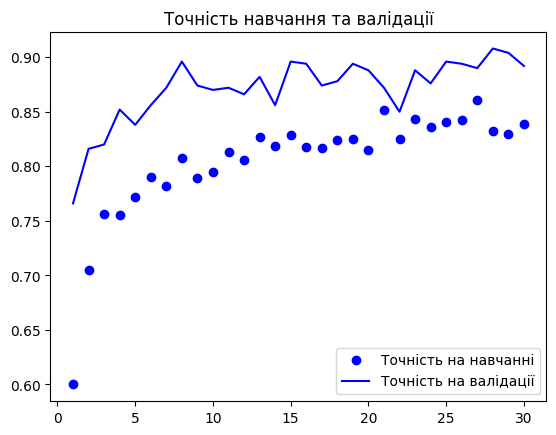

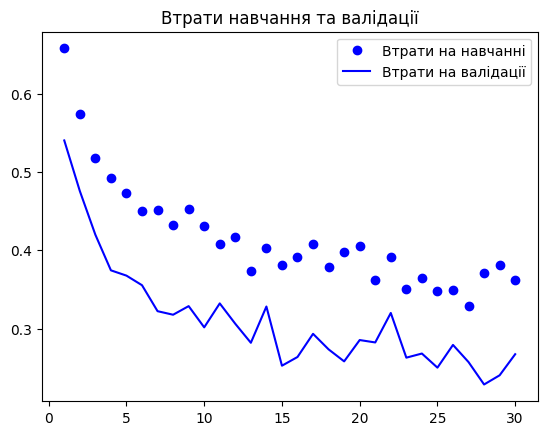

In [44]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Точність на навчанні')
plt.plot(epochs, val_acc, 'b', label='Точність на валідації')
plt.title('Точність навчання та валідації')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Втрати на навчанні')
plt.plot(epochs, val_loss, 'b', label='Втрати на валідації')
plt.title('Втрати навчання та валідації')
plt.legend()

plt.show()

## Save

In [45]:
model.save('cats_vs_dogs_vgg16.keras')

# Inception

In [22]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SIZE = (299, 299)
BATCH_SIZE = 16

train_datagen_inception = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen_inception = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator_inception = train_datagen_inception.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

validation_generator_inception = validation_datagen_inception.flow_from_directory(
    validation_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

base_model_inception = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [23]:
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

base_model_inception.trainable = False

model_inception = models.Sequential([
    base_model_inception,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

model_inception.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    33,554,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,357,729 (211.17 MB)

 Trainable params: 33,554,945 (128.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [24]:
from tensorflow.keras import optimizers

model_inception.compile(
    optimizer=optimizers.RMSprop(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['acc']
)

history_inception = model_inception.fit(
    train_generator_inception,
    steps_per_epoch=50,
    epochs=15,
    validation_data=validation_generator_inception,
    validation_steps=25,
    callbacks=[lr_scheduler]
)


Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 43s 533ms/step - acc: 0.8475 - loss: 0.3618 - val_acc: 0.9800 - val_loss: 0.0571 - learning_rate: 1.0000e-05
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 380ms/step - acc: 0.9718 - loss: 0.0826 - val_acc: 0.9850 - val_loss: 0.0565 - learning_rate: 1.0000e-05
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 401ms/step - acc: 0.9795 - loss: 0.0909 - val_acc: 0.9850 - val_loss: 0.0625 - learning_rate: 1.0000e-05
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 370ms/step - acc: 0.9613 - loss: 0.0940 - val_acc: 0.9900 - val_loss: 0.0304 - learning_rate: 1.0000e-05
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 393ms/step - acc: 0.9744 - loss: 0.0846 - val_acc: 0.9925 - val_loss: 0.0223 - learning_rate: 1.0000e-05
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 383ms/step - acc: 0.9630 - loss: 0.1173 - val_acc: 0.9900 - val_loss: 0.0218 - learning_rate: 1.0000e-05
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 373ms/step - acc: 0.9694 - loss: 0.1030 - val_acc: 0.9875 - val_loss: 0.0389

In [29]:
model_inception.save('cats_vs_dogs_inceptionv3.keras')

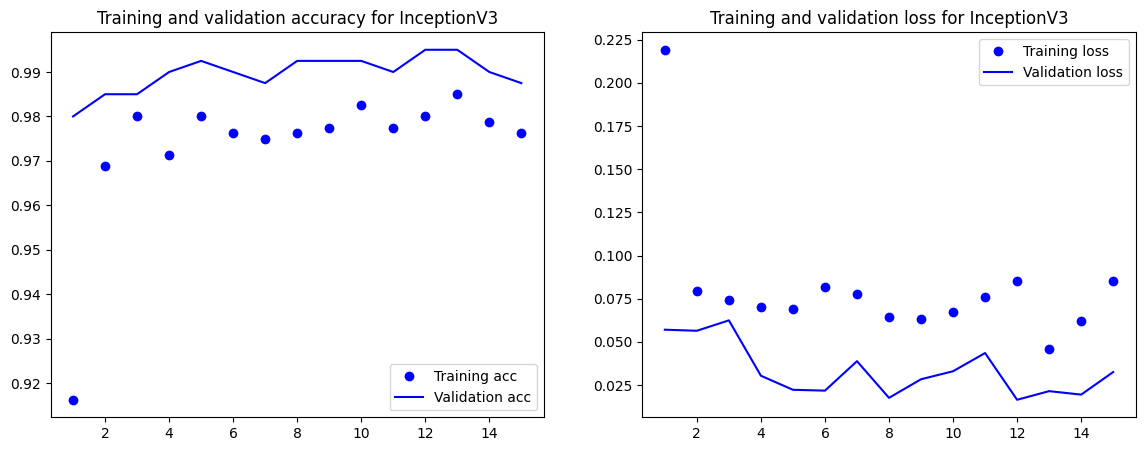

In [28]:
import matplotlib.pyplot as plt

def plot_history(history, model_name):
    acc = history.history['acc']
    val_acc = history.history['val_acc']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title(f'Training and validation accuracy for {model_name}')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title(f'Training and validation loss for {model_name}')
    plt.legend()

    plt.show()

plot_history(history_inception, "InceptionV3")

# ResNet50

In [25]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator


IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16

train_datagen_resnet = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen_resnet = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator_resnet = train_datagen_resnet.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

validation_generator_resnet = validation_datagen_resnet.flow_from_directory(
    validation_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

base_model_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [26]:
base_model_resnet.trainable = False

In [27]:
model_resnet = models.Sequential([
    base_model_resnet,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model_resnet.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,278,337 (187.98 MB)

 Trainable params: 25,690,625 (98.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [30]:
model_resnet.compile(
    optimizer=optimizers.RMSprop(learning_rate=2e-5),
    loss='binary_crossentropy',
    metrics=['acc']
)

history_resnet = model_resnet.fit(
    train_generator_resnet,
    steps_per_epoch=50,
    epochs=15,
    validation_data=validation_generator_resnet,
    validation_steps=25
)

Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 327ms/step - acc: 0.7854 - loss: 0.7046 - val_acc: 0.9925 - val_loss: 0.0244
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 375ms/step - acc: 0.9496 - loss: 0.1634 - val_acc: 0.9825 - val_loss: 0.0628
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 416ms/step - acc: 0.9392 - loss: 0.2335 - val_acc: 0.9800 - val_loss: 0.0768
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 228ms/step - acc: 0.9499 - loss: 0.1374 - val_acc: 0.9825 - val_loss: 0.0785
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 239ms/step - acc: 0.9599 - loss: 0.1566 - val_acc: 0.9675 - val_loss: 0.2218
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 239ms/step - acc: 0.9399 - loss: 0.2571 - val_acc: 0.9975 - val_loss: 0.0102
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 238ms/step - acc: 0.9519 - loss: 0.2326 - val_acc: 0.9900 - val_loss: 0.0267
Epoch 8/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 413ms/step - acc: 0.9799 - loss: 0.0917 - val_acc: 0.9900 - val_loss: 0.0534
Epoch 9/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 199ms/

In [31]:
model_resnet.save('cats_vs_dogs_resnet50.keras')

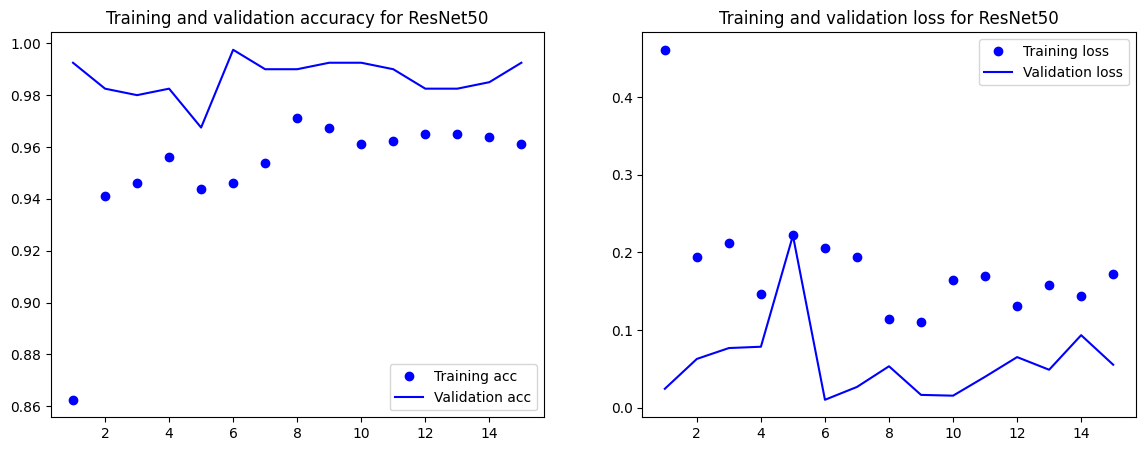

In [32]:
import matplotlib.pyplot as plt

def plot_history(history, model_name):
    acc = history.history['acc']
    val_acc = history.history['val_acc']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title(f'Training and validation accuracy for {model_name}')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title(f'Training and validation loss for {model_name}')
    plt.legend()

    plt.show()

plot_history(history_resnet, "ResNet50")

# Test

In [33]:
!cp /content/drive/MyDrive/deepl/lab08/test_images.zip /content/test_images.zip

In [34]:
!unzip "/content/test_images.zip" -d "/content/test_images"

Archive:  /content/test_images.zip
  inflating: /content/test_images/cat.3.png  
  inflating: /content/test_images/cat.4.png  
  inflating: /content/test_images/cat.5.png  
  inflating: /content/test_images/dog.1.png  
  inflating: /content/test_images/dog.2.png  
  inflating: /content/test_images/dog.3.png  
  inflating: /content/test_images/dog.4.png  
  inflating: /content/test_images/dog.5.png  
  inflating: /content/test_images/cat.1.png  
  inflating: /content/test_images/cat.2.png  


In [46]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import os
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess_input
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet50_preprocess_input
from tensorflow.keras.applications.inception_v3 import preprocess_input as inceptionv3_preprocess_input

print("TensorFlow version:", tf.__version__)

MODELS_PATH = './'
TEST_IMAGES_FOLDER = './test_images'

MODEL_CONFIG = {
    'VGG16': {
        'path': os.path.join(MODELS_PATH, 'cats_vs_dogs_vgg16.keras'),
        'target_size': (150, 150),
        'preprocess_func': vgg16_preprocess_input
    },
    'ResNet50': {
        'path': os.path.join(MODELS_PATH, 'cats_vs_dogs_resnet50.keras'),
        'target_size': (224, 224),
        'preprocess_func': resnet50_preprocess_input
    },
    'InceptionV3': {
        'path': os.path.join(MODELS_PATH, 'cats_vs_dogs_inceptionv3.keras'),
        'target_size': (299, 299),
        'preprocess_func': inceptionv3_preprocess_input
    }
}

print("Loading models...")
models = {}
for name, config in MODEL_CONFIG.items():
    try:
        models[name] = tf.keras.models.load_model(config['path'])
        print(f"- {name} model loaded successfully.")
    except Exception as e:
        print(f"Error loading {name} model from {config['path']}. Please check the file path.")
        print(e)

try:
    image_filenames = [f for f in os.listdir(TEST_IMAGES_FOLDER) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if not image_filenames:
        print(f"No images found in the folder: {TEST_IMAGES_FOLDER}. Please add some images.")
except FileNotFoundError:
    print(f"Error: The folder '{TEST_IMAGES_FOLDER}' was not found. Please create it and add your test images.")
    image_filenames = []

if not models or not image_filenames:
  print("\nCould not run predictions. Please ensure models are loaded and images are available.")
  exit(1)

for filename in image_filenames:
    img_path = os.path.join(TEST_IMAGES_FOLDER, filename)
    print(f"\n" + "="*40)
    print(f"ANALYZING IMAGE: {filename}")
    print("="*40)

    for name, model in models.items():
        config = MODEL_CONFIG[name]

        img = image.load_img(img_path, target_size=config['target_size'])
        img_array = image.img_to_array(img)
        img_array_expanded = np.expand_dims(img_array, axis=0)
        processed_img = config['preprocess_func'](img_array_expanded)

        prediction = model.predict(processed_img)
        score = prediction[0][0]

        if score < 0.5:
            result_label = "CAT"
        else:
            result_label = "DOG"

        print(f"[{name: <12}] Prediction: {result_label: <4} (Raw Score: {score:.4f})")


TensorFlow version: 2.19.0
Loading models...
- VGG16 model loaded successfully.
- ResNet50 model loaded successfully.
- InceptionV3 model loaded successfully.

ANALYZING IMAGE: dog.2.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
[VGG16       ] Prediction: DOG  (Raw Score: 1.0000)
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
[ResNet50    ] Prediction: DOG  (Raw Score: 1.0000)
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
[InceptionV3 ] Prediction: DOG  (Raw Score: 1.0000)

ANALYZING IMAGE: dog.4.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
[VGG16       ] Prediction: DOG  (Raw Score: 1.0000)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
[ResNet50    ] Prediction: DOG  (Raw Score: 0.9999)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
[InceptionV3 ] Prediction: DOG  (Raw Score: 0.9983)

ANALYZING IMAGE: cat.4.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[VGG16       ] Prediction: CAT  (Raw Score: 0.0000)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
[ResNet50    ] Prediction: CAT  (Raw Score: 0.0000)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
[Ince

## Copy models to Google Drive

In [48]:
mkdir -p /content/drive/MyDrive/deepl/lab08/models

In [49]:
!cp /content/cats_vs_dogs* /content/drive/MyDrive/deepl/lab08/models